# Gaussian HMM on H3K4me3 raw coverage — analysis notebook

Adapted from Liebe's `pyhhmm.ipynb` (ATAC-seq project) for the K562 H3K4me3 test (ENCSR000DWD, two isogenic replicates).


In [1]:
import glob
import os
import re

import numpy as np
import pandas as pd
import pyBigWig
import matplotlib.pyplot as plt
import seaborn as sns

## Paths & parameters

In [2]:
base_dir = '/projects/b1042/AmaralLab/yucheng/HMM_histone'

# where 02_pyhhmm.sh wrote its outputs
parameter_dir = os.path.join(base_dir, 'data/pyhhmm/K562_H3K4me3_raw')

# one of the original HMM input bigWigs, to compute sample size (n) -- first rep
reference_bw_dir = os.path.join(base_dir, 'data/K562_H3K4me3/raw_coverage_bw')
reference_bw_file = sorted(os.path.basename(p) for p in
                           glob.glob(os.path.join(reference_bw_dir, '*.rawCoverage.100bp.mean.bw')))[0]
print('reference bigWig:', reference_bw_file)

chrom = 'chr14'
resolution = 100

reference bigWig: ENCFF185YRK.rawCoverage.100bp.mean.bw


# AIC BIC num states

In [3]:
def parse_parameter_file(filepath):
    """
    Extracts k, replicate, final logL, means, and variances from a parameter file.
  
    """
    parsed_data = {'filepath': filepath}
    fname = os.path.basename(filepath)

    match_k = re.search(r'(\d+)states_parameters\.txt', fname)
    if not match_k:
        return None
    parsed_data['k'] = int(match_k.group(1))

    match_rep = re.search(r'\.(ENCFF\w+)\.', fname)
    if not match_rep:
        return None
    parsed_data['replicate'] = match_rep.group(1)

    with open(filepath) as f:
        content = f.read()

    # final logL = last 'Iteration i: x' line
    logL_lines = [l for l in content.split('\n') if l.strip().startswith('Iteration')]
    final_logL = None
    if logL_lines:
        m = re.search(r':\s*(-?\d+(\.\d+)?)', logL_lines[-1])
        if m:
            final_logL = float(m.group(1))
    if final_logL is None:
        print(f'Warning: no final logL in {fname}')
        return None
    parsed_data['logL'] = final_logL

    # emission means: 'State i (Color): Mean signal = x.xxxx'
    parsed_data['means'] = [float(m) for m in re.findall(r'Mean signal = (-?\d+\.?\d*)', content)]
    # variances: 'State i: Variance = x.xxxx'
    parsed_data['variances'] = [float(v) for v in re.findall(r'Variance = (-?\d+\.?\d*)', content)]

    if len(parsed_data['means']) != parsed_data['k'] or len(parsed_data['variances']) != parsed_data['k']:
        print(f'Warning: mean/variance count mismatch in {fname}')
    return parsed_data

In [4]:
def calculate_n_params(k, n_emissions=1, covariance_type='diagonal'):
    # (k-1) initial probs + k(k-1) transitions + k means + k diagonal variances
    assert covariance_type == 'diagonal'
    return (k - 1) + k * (k - 1) + k * n_emissions + k * n_emissions


def get_sample_size(bw_path, chrom, resolution):
    bw = pyBigWig.open(bw_path)
    if chrom not in bw.chroms():
        bw.close()
        return None
    n = int(np.ceil(bw.chroms()[chrom] / resolution))
    bw.close()
    return n

In [5]:
results = []
# flat directory (our layout), restricted to the analyzed chromosome
param_files = sorted(glob.glob(os.path.join(parameter_dir, f'*.{chrom}.*states_parameters.txt')))
print(f'found {len(param_files)} parameter files')

for filepath in param_files:
    parsed = parse_parameter_file(filepath)
    if parsed:
        results.append(parsed)

assert results, 'No parameter files parsed -- has 02_pyhhmm.sh finished?'

found 12 parameter files


In [6]:
df = pd.DataFrame(results).sort_values(['replicate', 'k']).reset_index(drop=True)
df[['replicate', 'k', 'logL']]

,replicate,k,logL
0,ENCFF185YRK,2,5.657202e+06
1,ENCFF185YRK,3,5.878790e+06
2,ENCFF185YRK,4,5.915455e+06
3,ENCFF185YRK,5,5.935415e+06
4,ENCFF185YRK,6,5.962081e+06
5,ENCFF185YRK,7,5.995261e+06
6,ENCFF955AMI,2,5.765688e+06
7,ENCFF955AMI,3,5.976452e+06
8,ENCFF955AMI,4,6.042512e+06
9,ENCFF955AMI,5,6.029738e+06


In [7]:
# calc sample size n
ref_bw_path = os.path.join(reference_bw_dir, reference_bw_file)
n_samples = get_sample_size(ref_bw_path, chrom, resolution)
assert n_samples is not None, 'chrom not in reference bigWig'
print(f'Calculated sample size (n_bins): {n_samples}')

Calculated sample size (n_bins): 1070438


In [8]:
# calc aic and bic
df['n_params'] = df['k'].apply(lambda k: calculate_n_params(k, n_emissions=1, covariance_type='diagonal'))

df['AIC'] = 2 * df['n_params'] - 2 * df['logL']
df['BIC'] = df['n_params'] * np.log(n_samples) - 2 * df['logL']
df[['replicate', 'k', 'n_params', 'logL', 'AIC', 'BIC']]

,replicate,k,n_params,logL,AIC,BIC
0,ENCFF185YRK,2,7,5.657202e+06,-1.131439e+07,-1.131431e+07
1,ENCFF185YRK,3,14,5.878790e+06,-1.175755e+07,-1.175738e+07
2,ENCFF185YRK,4,23,5.915455e+06,-1.183086e+07,-1.183059e+07
3,ENCFF185YRK,5,34,5.935415e+06,-1.187076e+07,-1.187036e+07
4,ENCFF185YRK,6,47,5.962081e+06,-1.192407e+07,-1.192351e+07
5,ENCFF185YRK,7,62,5.995261e+06,-1.199040e+07,-1.198966e+07
6,ENCFF955AMI,2,7,5.765688e+06,-1.153136e+07,-1.153128e+07
7,ENCFF955AMI,3,14,5.976452e+06,-1.195288e+07,-1.195271e+07
8,ENCFF955AMI,4,23,6.042512e+06,-1.208498e+07,-1.208470e+07
9,ENCFF955AMI,5,34,6.029738e+06,-1.205941e+07,-1.205900e+07


In [9]:
# calc avgs and std devs across reps
summary = df.groupby('k')[['AIC', 'BIC']].agg(['mean', 'std']).reset_index()
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]
print(summary)

   k      AIC_mean        AIC_std      BIC_mean        BIC_std
0  2 -1.142288e+07  153423.163780 -1.142279e+07  153423.163780
1  3 -1.185521e+07  138115.612519 -1.185505e+07  138115.612519
2  4 -1.195792e+07  179685.325584 -1.195765e+07  179685.325584
3  5 -1.196508e+07  133392.149686 -1.196468e+07  133392.149686
4  6 -1.208402e+07  226206.282213 -1.208346e+07  226206.282213
5  7 -1.207464e+07  119141.645281 -1.207391e+07  119141.645281


In [10]:
unique_replicates = df['replicate'].unique()

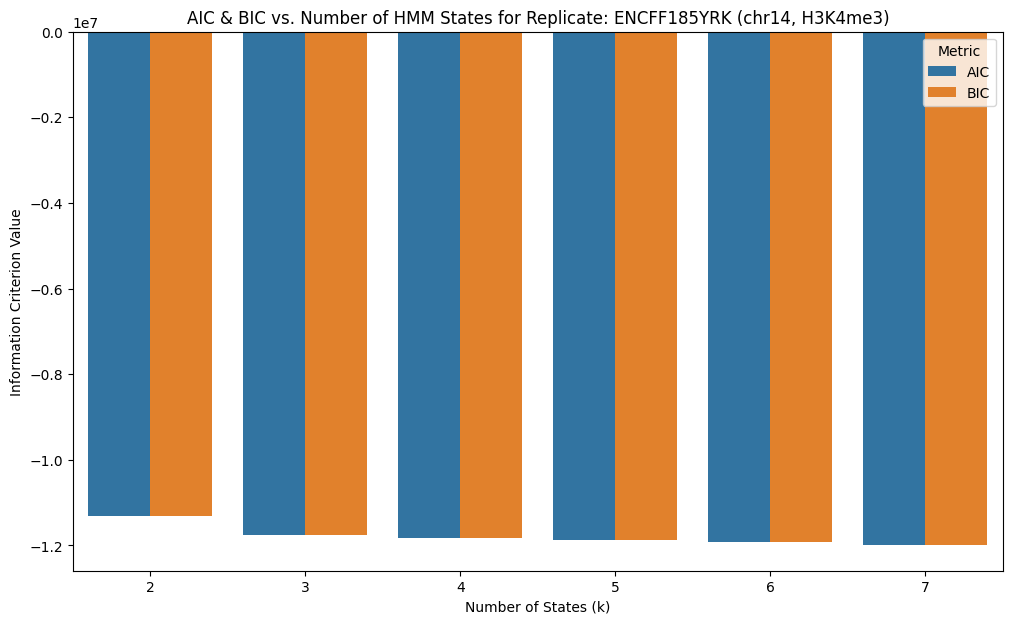

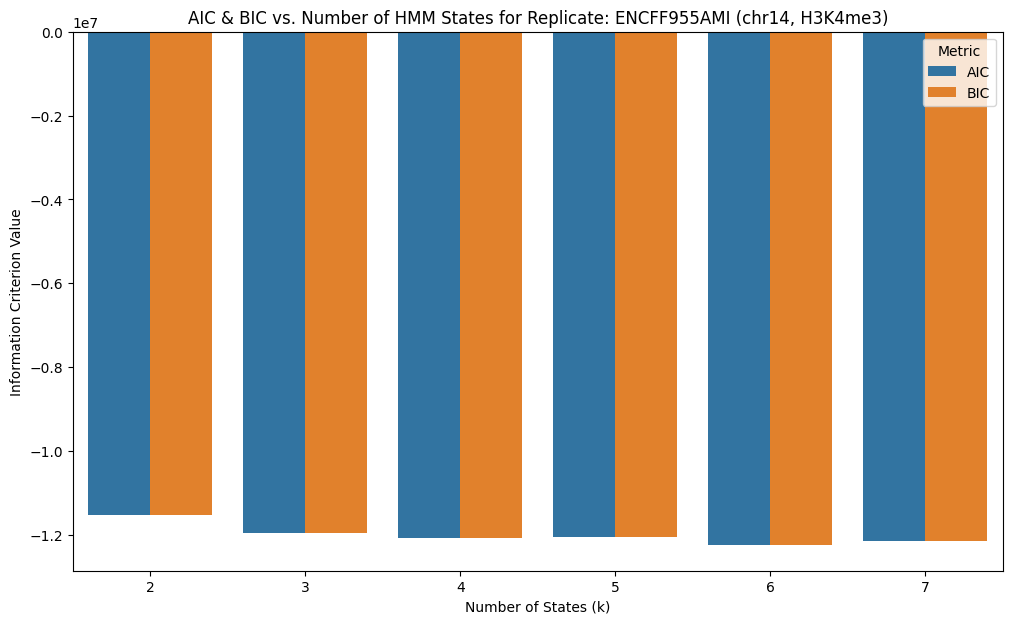

In [11]:
# plot aic and bic for each replicate
for rep in unique_replicates:
    rep_df = df[df['replicate'] == rep].sort_values(by='k')
    if rep_df.empty:
        continue
    rep_df_melted = pd.melt(rep_df, id_vars=['k'], value_vars=['AIC', 'BIC'],
                            var_name='Metric', value_name='Value')
    plt.figure(figsize=(12, 7))
    sns.barplot(x='k', y='Value', hue='Metric', data=rep_df_melted)
    plt.title(f'AIC & BIC vs. Number of HMM States for Replicate: {rep} ({chrom}, H3K4me3)')
    plt.xlabel('Number of States (k)')
    plt.ylabel('Information Criterion Value')
    plt.legend(title='Metric')

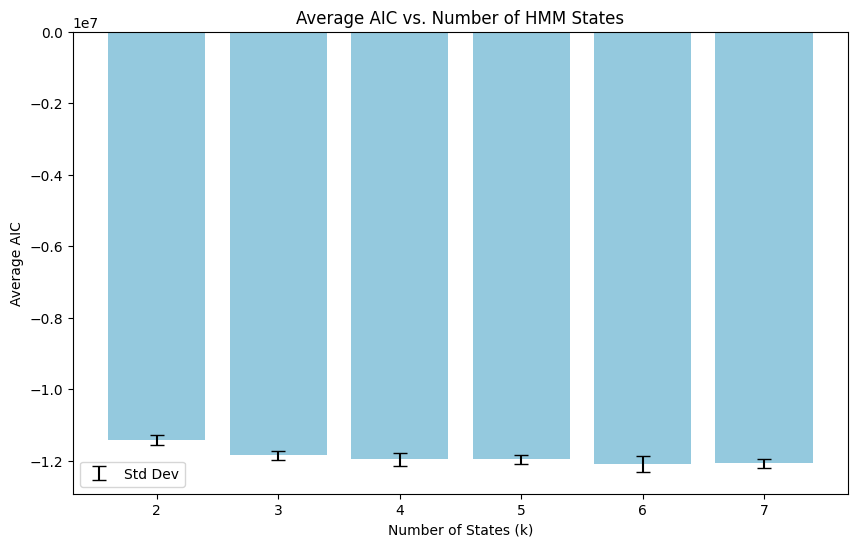

In [12]:
# avg aic
plt.figure(figsize=(10, 6))
sns.barplot(x='k', y='AIC_mean', data=summary, color='skyblue', errorbar=None)
plt.errorbar(x=np.arange(len(summary)), y=summary['AIC_mean'], yerr=summary['AIC_std'].fillna(0),
             fmt='none', c='black', capsize=5, label='Std Dev')
plt.title('Average AIC vs. Number of HMM States')
plt.xlabel('Number of States (k)')
plt.ylabel('Average AIC')
plt.legend()
plt.show()

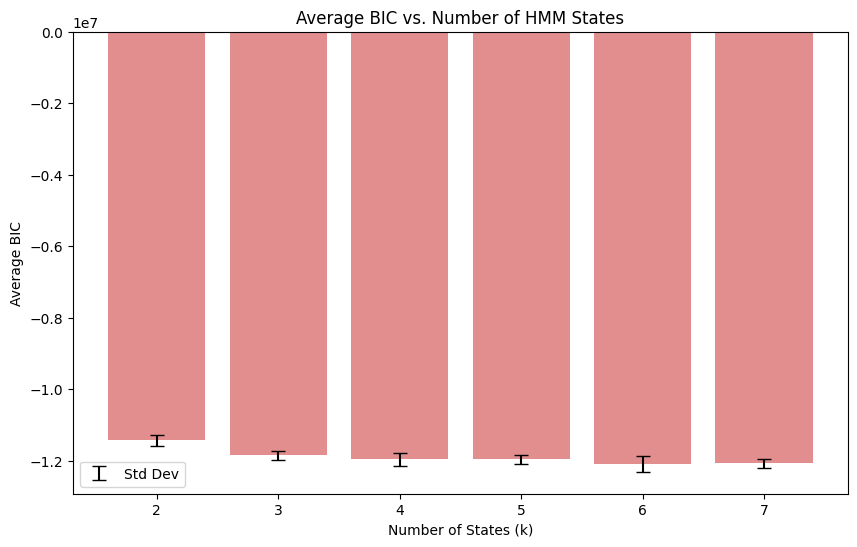

In [13]:
# avg bic
plt.figure(figsize=(10, 6))
sns.barplot(x='k', y='BIC_mean', data=summary, color='lightcoral', errorbar=None)
plt.errorbar(x=np.arange(len(summary)), y=summary['BIC_mean'], yerr=summary['BIC_std'].fillna(0),
             fmt='none', c='black', capsize=5, label='Std Dev')
plt.title('Average BIC vs. Number of HMM States')
plt.xlabel('Number of States (k)')
plt.ylabel('Average BIC')
plt.legend()
plt.show()

In [14]:
best = df.loc[df.groupby('replicate')['BIC'].idxmin(), ['replicate', 'k', 'BIC']]
print('Best k by BIC per replicate:')
print(best.to_string(index=False))

Best k by BIC per replicate:
  replicate  k           BIC
ENCFF185YRK  7 -1.198966e+07
ENCFF955AMI  6 -1.224341e+07


## compare means and covs across states

In [15]:
k_colors = plt.get_cmap('viridis', len(df['k'].unique()))

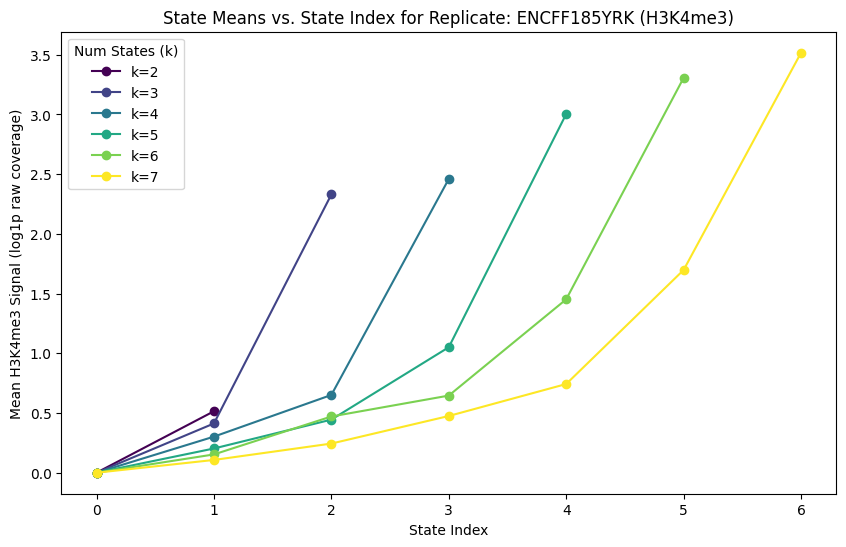

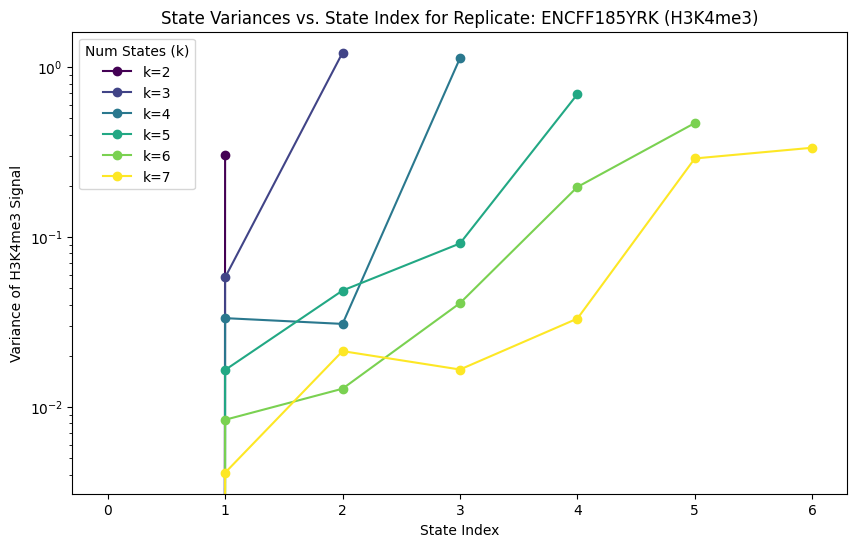

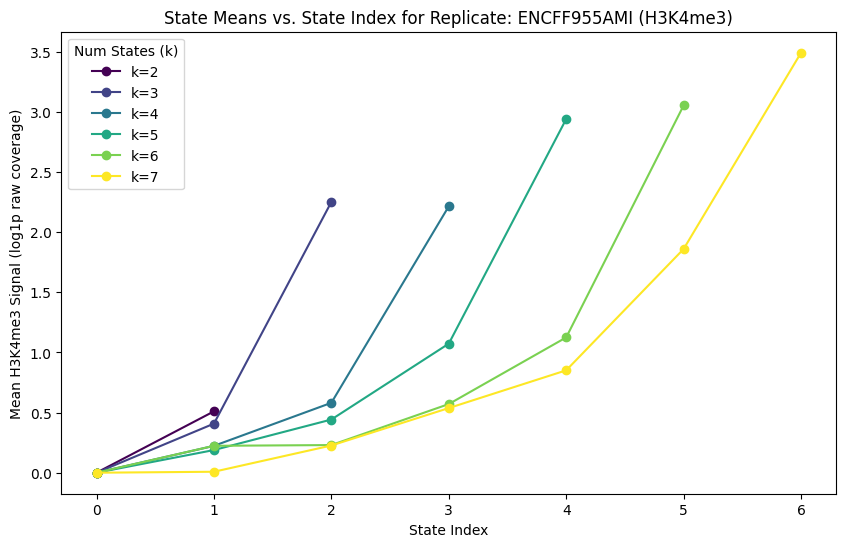

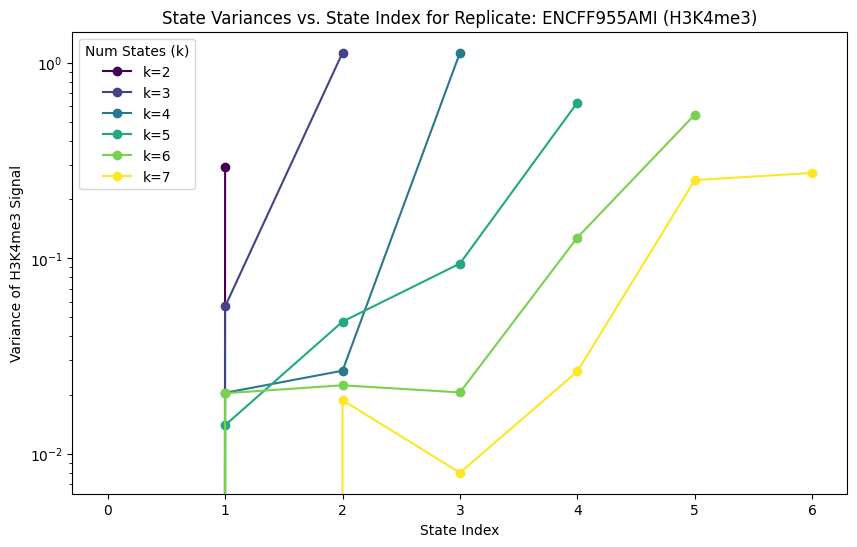

In [16]:
for rep in unique_replicates:
    rep_df = df[df['replicate'] == rep].sort_values(by='k')
    if rep_df.empty:
        continue

    # plot means vs states
    plt.figure(figsize=(10, 6))
    for idx, k_val in enumerate(sorted(rep_df['k'].unique())):
        row = rep_df[rep_df['k'] == k_val].iloc[0]
        plt.plot(range(k_val), row['means'], marker='o', linestyle='-', color=k_colors(idx), label=f'k={k_val}')
    plt.title(f'State Means vs. State Index for Replicate: {rep} (H3K4me3)')
    plt.xlabel('State Index')
    plt.ylabel('Mean H3K4me3 Signal (log1p raw coverage)')
    plt.xticks(np.arange(df['k'].max()))
    plt.legend(title='Num States (k)')

    # plot variances vs states
    plt.figure(figsize=(10, 6))
    for idx, k_val in enumerate(sorted(rep_df['k'].unique())):
        row = rep_df[rep_df['k'] == k_val].iloc[0]
        plt.plot(range(k_val), row['variances'], marker='o', linestyle='-', color=k_colors(idx), label=f'k={k_val}')
    plt.title(f'State Variances vs. State Index for Replicate: {rep} (H3K4me3)')
    plt.xlabel('State Index')
    plt.ylabel('Variance of H3K4me3 Signal')
    plt.xticks(np.arange(df['k'].max()))
    plt.legend(title='Num States (k)')
    plt.yscale('log')

## coefficient of variance vs k

In [17]:
# cv = std dev / |mean|
# add epsilon to avoid divide-by-zero
df['cvs'] = df.apply(
    lambda row: [
        np.sqrt(var) / (abs(mean) + 1e-9)
        for var, mean in zip(row['variances'], row['means'])
    ],
    axis=1
)

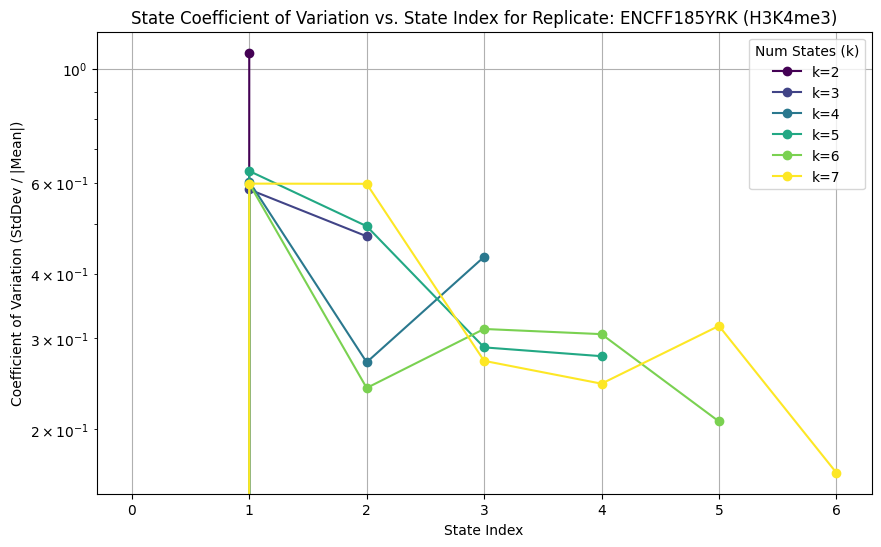

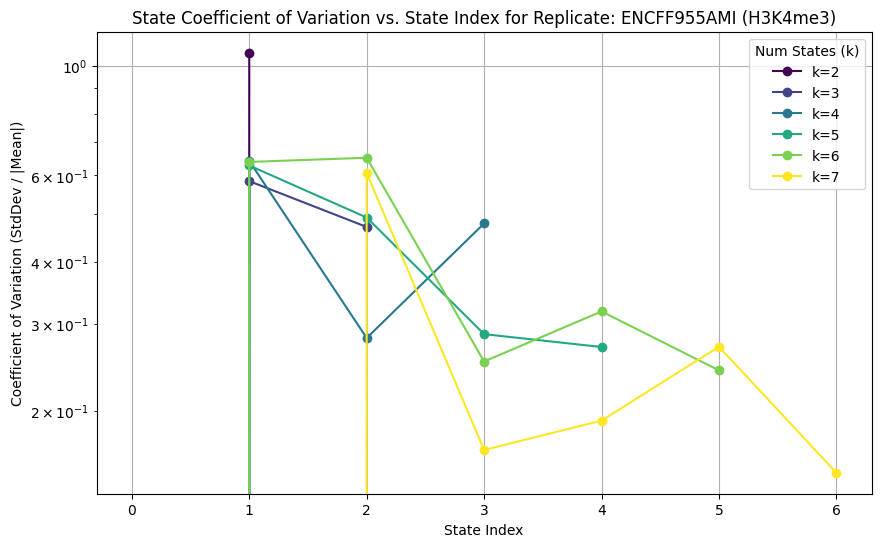

In [18]:
df = df.sort_values(by=['replicate', 'k'])

for rep in unique_replicates:
    rep_df = df[df['replicate'] == rep].sort_values(by='k')
    if rep_df.empty:
        continue
    plt.figure(figsize=(10, 6))
    for idx, k_val in enumerate(sorted(rep_df['k'].unique())):
        row = rep_df[rep_df['k'] == k_val].iloc[0]
        plt.plot(range(k_val), row['cvs'], marker='o', linestyle='-', color=k_colors(idx), label=f'k={k_val}')
    plt.title(f'State Coefficient of Variation vs. State Index for Replicate: {rep} (H3K4me3)')
    plt.xlabel('State Index')
    plt.ylabel('Coefficient of Variation (StdDev / |Mean|)')
    plt.yscale('log')
    plt.xticks(np.arange(df['k'].max()))
    plt.legend(title='Num States (k)')
    plt.grid(True)

## Liebe's ATAC observation for reference: CV plateaued for 5-7 state models
## => no new "stable" states => diminishing returns beyond that.
## Question for H3K4me3: does the same plateau appear, and at the same k?

## replicate concordance (new for the isogenic-replicate design)

Quick numeric check: for the BIC-best k, how similar are the two replicates' state sequences?

In [19]:
def load_state_sequence(regions_bed):
    states = []
    with open(regions_bed) as f:
        for line in f:
            if line.startswith('track'):
                continue
            states.append(int(line.split('\t')[3].replace('state_', '')))
    return np.array(states)

k_best = int(best['k'].mode()[0])  # most common best-k across reps
seqs = {}
for rep in unique_replicates:
    bed = glob.glob(os.path.join(parameter_dir, f'*.{chrom}.{rep}.{k_best}states_regions.bed'))
    if bed:
        seqs[rep] = load_state_sequence(bed[0])

if len(seqs) == 2:
    (r1, s1), (r2, s2) = seqs.items()
    L = min(len(s1), len(s2))
    agree = (s1[:L] == s2[:L]).mean()
    print(f'k={k_best}: exact per-bin state agreement {r1} vs {r2}: {agree:.3f}')
    print('(isogenic replicates -- expect this to be high)')

k=6: exact per-bin state agreement ENCFF185YRK vs ENCFF955AMI: 0.604
(isogenic replicates -- expect this to be high)
